In [10]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
import math
import re

import sys
sys.path.append('../../../')
# from mount_drive import mount_s_drive

In [11]:
import pandas as pd
import os
import sys
dir1 = os.path.abspath(os.path.join(os.getcwd(), '../../analysisFunctions'))
sys.path.insert(0, dir1)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, roc_auc_score, make_scorer, auc, roc_curve
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from xgboost import XGBClassifier, XGBRegressor, plot_tree, plot_importance, to_graphviz
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from graphviz import Source
from sklearn import tree
from sklearn.svm import SVC, LinearSVC, SVR
import re
from machine_learning import *
from hyperion_utils import *
# import doubleml as dml
import pymc as pm
import pymc_bart as pmb
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
# import causalpy as cp
import pymc_bart as pmb
import arviz as az

In [12]:
myDfs = readDfs()

In [13]:
print(myDfs['Description_tables_variables'][['Tables', 'Variable', 'LabelTranslated', 'Label']].to_string())

         Tables                          Variable                                                                                       LabelTranslated                                                                                                 Label
0           ADL                            SUBJID                                                                      Subject Identifier for the Study                                                                      Subject Identifier for the Study
1           ADL                             ADL_0                                                                      Le score ADL a t-il été complété                                                                      Le score ADL a t-il été complété
2           ADL                        ADL_1_TEMP                                                  Hygiène corporelle (champ intermediaire pour saisie)                                                  Hygiène corporelle (champ intermediai

In [14]:
bio_data_columns = list(myDfs['Description_tables_variables']['Variable'].iloc[52:76])
bio_data_columns.append('SUBJID')
bio_data_columns_descr = list(myDfs['Description_tables_variables']['Label'].iloc[52:76])
bio_visit_column = 'VISIT'
cpc_column = 'CPC_SC3'
group_colums = ['V0_BRAS2', 'groupe']
ds_columns = 'DS_DATA_REFUS'
ecg_columns = list(myDfs['Description_tables_variables']['Variable'].iloc[137:154])
ecg_columns_descr = list(myDfs['Description_tables_variables']['LabelTranslated'].iloc[137:154])
j0_drop_columns = list(myDfs['Description_tables_variables']['Variable'].iloc[362:384])
j0_reflex_columns = list(myDfs['Description_tables_variables']['Variable'].iloc[273:285])
j0_reflex_columns_descr = list(myDfs['Description_tables_variables']['LabelTranslated'].iloc[273:285])
sofa_columns = list(myDfs['Description_tables_variables']['Variable'].iloc[586:593])
sofa_columns.append('SUBJID')
ei_columns = list(myDfs['Description_tables_variables']['Variable'].iloc[158:168])
ei_columns = ei_columns + (['SUBJID', 'EI_ARYTHMI', 'EI_ANTIEPILEPTIQ'])

In [15]:
myPredictorsDf = pd.read_csv('./predictorsDf.csv')

In [24]:
myXValue = myPredictorsDf.drop(columns= ['CPC_SC3', 'CPC12', 'J0_SEX', 'SUBJID', 'BARTHEL_SC', 'SOFA_SC7', 'DS_DC', 'DAYS_ALIVE_30', 'J0_GLASGOW_CONTROLE', 'J0_CORDA_DOS'])
myFilter = myPredictorsDf['groupe'] != 2
myXValue = myXValue[myFilter]
myYValue = myPredictorsDf['CPC12']
X_train, X_test, y_train, y_test = train_test_split(myXValue, myYValue, stratify=myPredictorsDf[myFilter][['CPC12', 'groupe']], test_size=0.30, random_state = 42)

In [25]:
myPipeline

/home/mbranda1/.local/lib/python3.11/site-packages/sklearn/compose/_column_transformer.py:1624: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder=OneHotEncoder(handle_unknown='ignore',
                                                           sparse_output=False),
                                   transformers=[('num', StandardScaler(),
                                                  Index(['J0_TAILLE', 'J0_POIDS', 'J0_BMI', 'J0_AGE', 'J0_PAS', 'J0_PAD',
       'J0_PAM', 'J0_FC', 'J0_SPO2', 'J0_GLASGOW', 'J0_MOTRICE', 'J0_TEMP',
       'J0_IGSII', 'J0_CHARLSON', 'J0_CAUSE2_ACR', 'J0_NOFLOW', 'J0_LOWFLOW...
       'J0_NORA', 'J0_ADRE2', 'J0_DOBU', 'ECG', 'ECG_ANOMALI', 'ECG_SUS_ST',
       'ECG_SOUS_ST', 'ECG_BAVI', 'ECG_BAVII', 'ECG_BAVIII', 'ECG_BBG',
       'ECG_BBD', 'ECG_TACHICARD', 'ECG_FIBRIL', 'ECG_SALV_VENT', 'ECG_FLUTER',
       'ECG_SALV_SUPRA', 'EI_EI', 'EI_HEMOSEVER', 'EI_TRANSFUS', 'EI_INTRACER',
       'EI_OAP', 'EI_ECHO', 'EI_DIURETIQ', 'EI_ANTIEPILEPTIQ', 'SEX'],
      dtype='object'))])),
                ('imputer', KNNImputer(n_neighbors=10))])

In [26]:
myPipeline = Pipeline(getDefaultPipelineSteps(X_train))
X_train_pre = myPipeline.fit_transform(X_train)
X_test_pre = myPipeline.transform(X_test)

with pm.Model() as model:
    X_shared = pm.Data('X_shared', X_train_pre)
    y_shared = pm.Data('y_shared', y_train)
    u = pmb.BART('u', X = X_shared, Y= y_train, m=50)
    p = 1 / (1 + np.exp(-u))
    y_obs= pm.Bernoulli('y_obs', p=p, observed = y_shared)
    trace = pm.sample(50, return_inferencedata=True)
    # trace = az.from_netcdf('bart_model_tracedc.nc')
# Save trace 
# az.to_netcdf(trace, 'bart_model_tracedc.nc')

Only 50 samples per chain. Reliable r-hat and ESS diagnostics require longer chains for accurate estimate.
Multiprocess sampling (4 chains in 4 jobs)
PGBART: [u]


/home/mbranda1/.local/lib/python3.11/site-packages/rich/live.py:256: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 50 draw iterations (4_000 + 200 draws total) took 13 seconds.
The number of samples is too small to check convergence reliably.


In [27]:
with model:
    pm.set_data({'X_shared': X_train_pre, 'y_shared': y_train})
    p_pred = pm.sample_posterior_predictive(trace, var_names=['y_obs'])
    # Calculate the mean predicted probability
    predicted_probs = p_pred['posterior_predictive']['y_obs'].mean(axis=0).mean(axis=0).data

threshold = 0.5
predictions = (predicted_probs > threshold).astype(int)
from sklearn.metrics import roc_auc_score, accuracy_score

# Calculate ROC AUC
roc_auc = roc_auc_score(y_train, predicted_probs)

# Calculate accuracy
accuracy = accuracy_score(y_train, predictions)

print(f'ROC AUC: {roc_auc:.2f}')
print(f'Accuracy: {accuracy:.2f}')

Sampling: [y_obs]


/home/mbranda1/.local/lib/python3.11/site-packages/rich/live.py:256: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

ROC AUC: 0.98
Accuracy: 0.94


In [28]:
with model:
    pm.set_data({'X_shared': X_test_pre, 'y_shared': y_test})
    p_pred = pm.sample_posterior_predictive(trace, var_names=['y_obs'])
    predicted_probs = p_pred['posterior_predictive']['y_obs'].mean(axis=0).mean(axis=0).data

threshold = 0.5
predictions = (predicted_probs > threshold).astype(int)
from sklearn.metrics import roc_auc_score, accuracy_score

# Calculate ROC AUC
roc_auc = roc_auc_score(y_test, predicted_probs)

# Calculate accuracy
accuracy = accuracy_score(y_test, predictions)

print(f'ROC AUC: {roc_auc:.2f}')
print(f'Accuracy: {accuracy:.2f}')

Sampling: [u, y_obs]


/home/mbranda1/.local/lib/python3.11/site-packages/rich/live.py:256: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

ROC AUC: 0.88
Accuracy: 0.92


(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'HYPERION BART Calibration Plot'}, xlabel='Mean predicted probability', ylabel='Observed event rate'>)

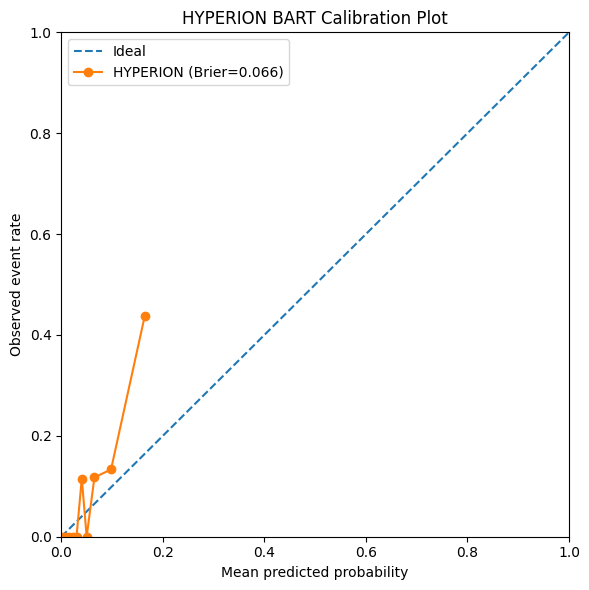

In [29]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import brier_score_loss, roc_auc_score
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

def calibration_intercept_slope(y_true, y_prob, eps=1e-6):
    """
    Compute calibration intercept and slope by regressing outcome on logit(predicted probability).
    Ideal intercept = 0, slope = 1.
    """
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_prob = np.clip(y_prob, eps, 1 - eps)

    logit_p = np.log(y_prob / (1 - y_prob))
    X = sm.add_constant(logit_p)

    fit = sm.Logit(y_true, X).fit(disp=False)

    intercept = fit.params[0]
    slope = fit.params[1]

    return intercept, slope

def calibration_metrics(y_true, y_prob):
    """
    Return a small dict of discrimination + calibration metrics.
    """
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)

    intercept, slope = calibration_intercept_slope(y_true, y_prob)

    return {
        "n": len(y_true),
        "event_rate": float(np.mean(y_true)),
        "auc": float(roc_auc_score(y_true, y_prob)),
        "brier": float(brier_score_loss(y_true, y_prob)),
        "calibration_intercept": float(intercept),
        "calibration_slope": float(slope),
    }

def plot_calibration_curve_one(y_true, y_prob, title="", n_bins=10, ax=None):
    """
    Reliability diagram / calibration curve.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))

    frac_pos, mean_pred = calibration_curve(
        y_true,
        y_prob,
        n_bins=n_bins,
        strategy="quantile"
    )

    ax.plot([0, 1], [0, 1], linestyle="--")
    ax.plot(mean_pred, frac_pos, marker="o")
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Observed event rate")
    ax.set_title(title)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    return ax
def plot_calibration_curve_multi(model_preds, y_true, title="", n_bins=10):
    """
    model_preds: dict like {"XGBoost": probs1, "NN": probs2, "BART": probs3}
    """
    fig, ax = plt.subplots(figsize=(6, 6))

    ax.plot([0, 1], [0, 1], linestyle="--", label="Ideal")

    for model_name, y_prob in model_preds.items():
        frac_pos, mean_pred = calibration_curve(
            y_true,
            y_prob,
            n_bins=n_bins,
            strategy="quantile"
        )
        brier = brier_score_loss(y_true, y_prob)
        ax.plot(mean_pred, frac_pos, marker="o", label=f"{model_name} (Brier={brier:.3f})")

    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Observed event rate")
    ax.set_title(title)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend()

    plt.tight_layout()
    return fig, ax

def build_calibration_table(results_dict):
    """
    results_dict structure:
    {
        ("eICU", "Neuro", "XGBoost"): (y_true, y_prob),
        ("eICU", "Neuro", "NN"): (y_true, y_prob),
        ...
    }
    """
    rows = []

    for (dataset, outcome, model), (y_true, y_prob) in results_dict.items():
        m = calibration_metrics(y_true, y_prob)
        m.update({
            "dataset": dataset,
            "outcome": outcome,
            "model": model
        })
        rows.append(m)

    df = pd.DataFrame(rows)
    df = df[
        [
            "dataset", "outcome", "model", "n", "event_rate",
            "auc", "brier", "calibration_intercept", "calibration_slope"
        ]
    ].sort_values(["dataset", "outcome", "model"]).reset_index(drop=True)

    return df
# y_pred_prob = model.predict(X_test)[:, 1]

results_dict = {
    ("eICU", "Mortality", "NN"): (y_test, predicted_probs),
    # ...
}

calib_table = build_calibration_table(results_dict)
calib_table.round(3)
plot_calibration_curve_multi({"HYPERION":predicted_probs}, y_test, "HYPERION BART Calibration Plot")

In [31]:
calib_table

,dataset,outcome,model,n,event_rate,auc,brier,calibration_intercept,calibration_slope
0,eICU,Mortality,NN,175,0.08,0.877329,0.065559,2.72419,1.855952


In [22]:
myXValueModified1 = X_test.copy()
myXValueModified1['groupe'] = 1.0
myXValueModified2 = X_test.copy()
myXValueModified2['groupe'] = 0.0
with model:
    pm.set_data({'X_shared': myPipeline.transform(myXValueModified1), 'y_shared': y_test})
    p_pred = pm.sample_posterior_predictive(trace, var_names=['y_obs'])
    predicted_probs1 = p_pred['posterior_predictive']['y_obs'].mean(axis=0).mean(axis=0).data

with model:
    pm.set_data({'X_shared': myPipeline.transform(myXValueModified2), 'y_shared': y_test})
    p_pred = pm.sample_posterior_predictive(trace, var_names=['y_obs'])
    predicted_probs2 = p_pred['posterior_predictive']['y_obs'].mean(axis=0).mean(axis=0).data



Sampling: [u, y_obs]


/home/mbranda1/.local/lib/python3.11/site-packages/rich/live.py:256: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling: [u, y_obs]


/home/mbranda1/.local/lib/python3.11/site-packages/rich/live.py:256: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

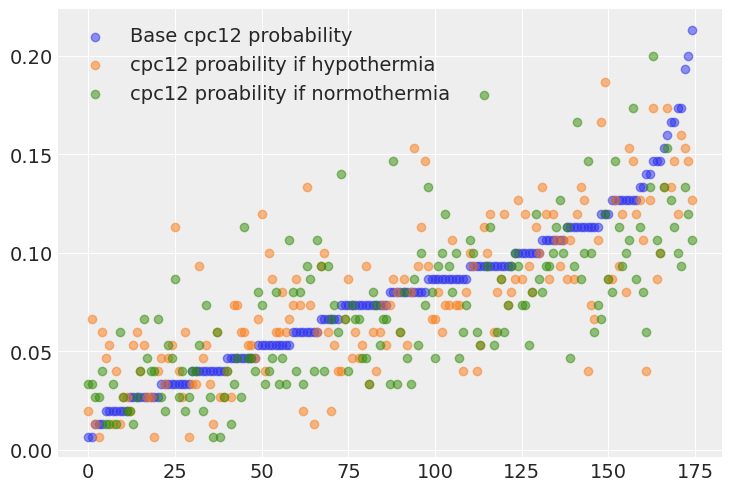

In [35]:
myYPred =  (predicted_probs1 - predicted_probs2)
myYPred = predicted_probs
myDfPreds = pd.DataFrame()
myDfPreds['base'] = predicted_probs
myDfPreds['group1'] = predicted_probs1
myDfPreds['group2'] = predicted_probs2
myDfPreds.sort_values(by=['base'], inplace=True)
plt.scatter(x = range(len(predicted_probs1)), y = myDfPreds['base'], alpha = 0.5)
plt.scatter(x = range(len(predicted_probs1)), y = myDfPreds['group1'], alpha = 0.5)
plt.scatter(x = range(len(predicted_probs1)), y = myDfPreds['group2'], alpha = 0.5)
plt.legend(['Base cpc12 probability', 'cpc12 proability if hypothermia', 'cpc12 proability if normothermia'])


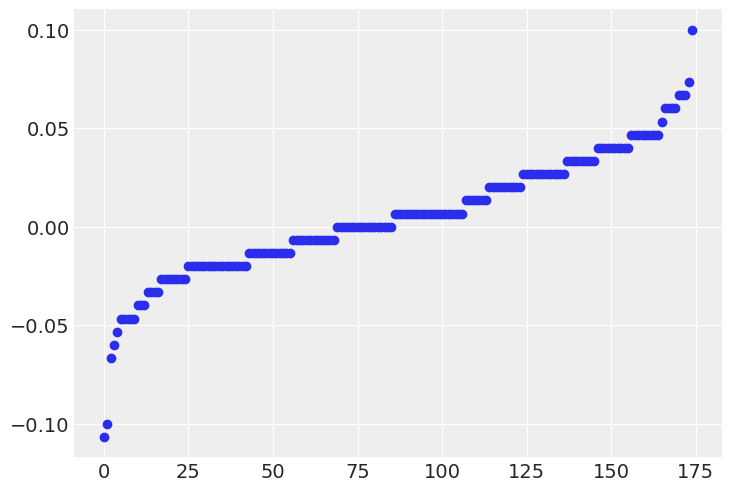

In [36]:
myDfPreds['diffs'] = (myDfPreds['group1'] - myDfPreds['group2'])
# myDfPreds['diffsscaled'] =  myDfPreds['diffs'] / myDfPreds['base']
myDfPreds.sort_values(by=['diffs'], inplace=True)
plt.scatter(x = range(len(predicted_probs1)), y = myDfPreds['diffs'])

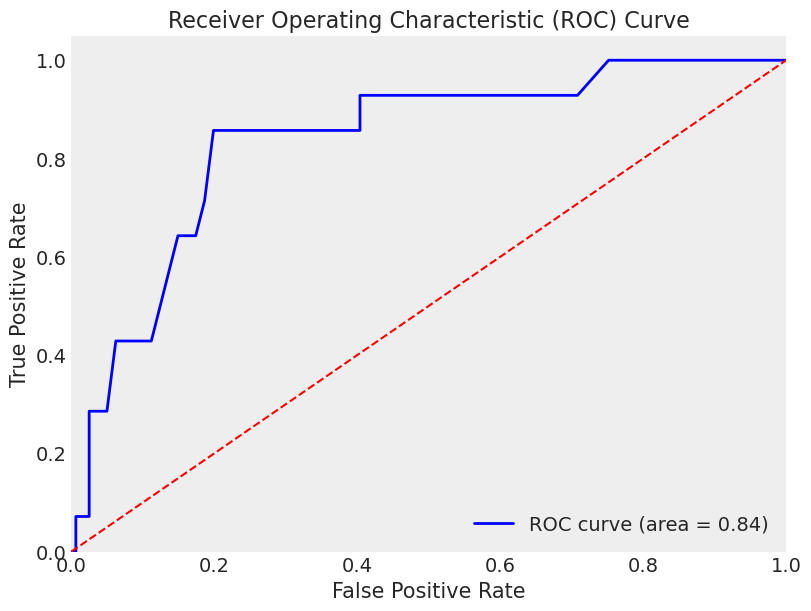

In [37]:
fpr, tpr, thresholds = roc_curve(y_test, predicted_probs)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Random classifier
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid()
plt.show()

In [38]:
def getTreatmentEffectDiff(X_train, y_train, myNewDf, aCategory = 'CPC12'):
    myData = pd.concat([X_train['groupe'], myNewDf['predicted_effect_group'], y_train], axis=1)
    model1 = smf.logit(
        f'{aCategory} ~ predicted_effect_group + groupe',
        data=myData
    ).fit()

    model2 = smf.logit(
        f'{aCategory} ~ predicted_effect_group * groupe',
        data=myData
    ).fit()

    llr = -2*(model1.llf - model2.llf)
    df_diff = model2.df_model - model1.df_model
    p_value = chi2.sf(llr, df_diff)

    print(f'Likelihood ratio of test results:')
    print(f'Chi square statistic: {llr}')
    print(f'p-value: {p_value}')
    print(f'Degress of freedom: {df_diff}')
    return p_value

def plotPredictedTreatmentEffect(myNewDf, aCategory = 'CPC12'):
    lower_third, upper_third, myNewDf = getPredictedThirds(myNewDf)
    if lower_third == upper_third:
        plt.scatter(x = range(len(y_pred_proba1)), y = myNewDf['predicted_effect'].sort_values())
    else:
        myNewDf.sort_values(['predicted_effect'], inplace=True)
        myNewDf.reset_index(inplace=True)
        for group in myNewDf['predicted_effect_group']:
            myFilter = myNewDf['predicted_effect_group'] == group
            plt.scatter(x = myNewDf[myFilter]['predicted_effect'].index, y = myNewDf[myFilter]['predicted_effect'])
        plt.legend(myNewDf['predicted_effect_group'].unique())
    plt.title(f'Predicted treatment effect diff between hypothermia and normothermia for {aCategory}')
    return lower_third, upper_third, myNewDf


In [39]:
myNewDf = pd.DataFrame()
myNewDf['predicted_effect'] = myYPred

Optimization terminated successfully.
         Current function value: 0.327036
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.323339
         Iterations 7
Likelihood ratio of test results:
Chi square statistic: 1.2937799098752265
p-value: 0.5236718899833719
Degress of freedom: 2.0


C:\Program Files\miniconda3\lib\site-packages\patsy\util.py:672: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return _pandas_is_categorical_dtype(dt)
C:\Program Files\miniconda3\lib\site-packages\patsy\util.py:672: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return _pandas_is_categorical_dtype(dt)
C:\Program Files\miniconda3\lib\site-packages\patsy\util.py:672: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return _pandas_is_categorical_dtype(dt)
C:\Program Files\miniconda3\lib\site-packages\patsy\util.py:672: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return _pandas_is_catego

0.5236718899833719

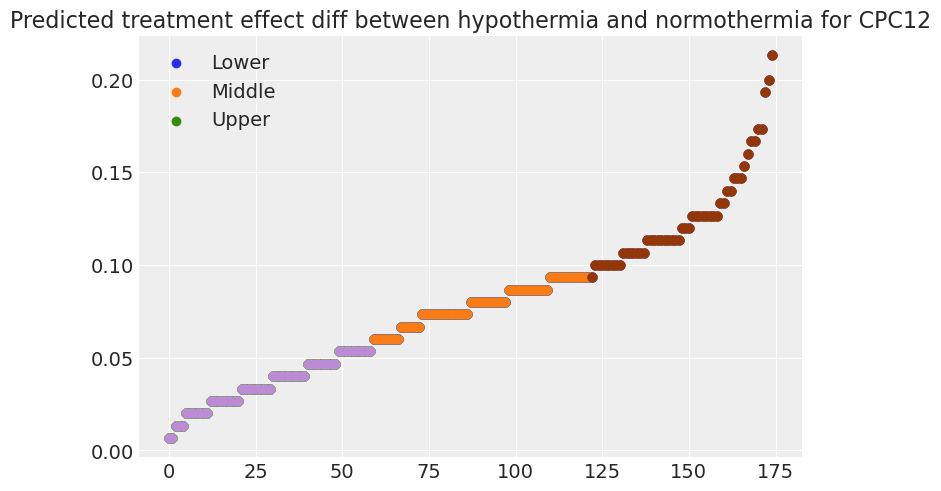

In [40]:
low_third, upper_third, myNewDf = plotPredictedTreatmentEffect(myNewDf)
getTreatmentEffectDiff(myXValue, myYValue, myNewDf)